## Baselines

In [12]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
import pickle as pl
import json
import re
import torch

In [2]:
# Sample from the bimodal beta distribution (p=0.5, a=1, b=14)
# Sample numbers from it to create a huge list of proportions 
# Get a range of of the min mean MAE deviation and max mean MAE deviation from centroid (min deviation: 0.0, max deviation: 0.40)
# Divide into different bins 
# Sample from the huge list of proportions to get the required no of proportions (eg 50 ) such that the distribution of the mean MAE deviation from centroid (each class has balanced proportion (e.g 1/no_of_classes))  is uniform. 

In [3]:
def sample_bimodal_beta(n=5000, p=0.5, a=2, b=90):
    """
    Generate samples from a bimodal distribution on [0,1] using a mixture of two Beta distributions.

    With probability p:
        sample from Beta(a, b) → concentrated near 0
    Otherwise:
        sample from Beta(b, a) → concentrated near 1

    This creates a bimodal shape with peaks near 0 and 1.
    """
    xs = []
    for _ in range(n):
        if random.random() < p:
            xs.append(random.betavariate(a, b))
        else:
            xs.append(random.betavariate(b, a))
    return xs

In [4]:
def generate_vectors(num_classes, no_of_examples):
    """
    Generate unique normalized proportion vectors.

    - Each vector sums to 1
    - Avoids duplicates
    - Avoids already existing vectors from dataset
    """

    seen = set()

    vectors = []

    while len(vectors) < no_of_examples:
        
        # Sample raw values from bimodal beta
        v = sample_bimodal_beta(n=num_classes, p=0.5, a=1, b=14)

        # Normalize to sum to 1
        s = sum(v)
        v = tuple(round(x / s, 3) for x in v)

        # Fix rounding drift (important)
        diff = 1.0 - sum(v)
        v = list(v)
        v[0] = round(v[0] + diff, 3)
        v = tuple(v)

        # Validate
        if v in seen or min(v) < 0.01 or sum(v)!=1:
            continue

        seen.add(v)
        vectors.append(v)

    return vectors

### Baseline 1  (centroid guess)

##### have 1/no_of_classes as the prediction and sample from the distribution that we usually use and compute the MAE

In [5]:

# 3
# Mean MAE:0.21995861111111123  0.220
# Mean MSE: 0.07176353055555558  0.072

# 4 
# Mean MAE: 0.17877062500000007  0.179
# Mean MSE: 0.04794908812500004  0.048

# 5
# Mean MAE: 0.14886249999999987   0.149
# Mean MSE: 0.03247563900000003   0.032

In [6]:
num_classes = 10
num_examples = 800

In [7]:
def give_MAE(X, no_of_classes, ddof=0):
    """
    X: array shape (N,no_of_classes) with values in [0,1]
    
    returns:
    P: normalized proportions, shape (N,no_of_classes)
    """
    X = np.asarray(X, dtype=float)
    l1 = np.mean(np.abs(X - float(1/no_of_classes)), axis=1)
    return l1

In [8]:
def give_MSE(X, no_of_classes, ddof=0):
    """
    X: array shape (N,no_of_classes) with values in [0,1]
    
    returns:
    P: normalized proportions, shape (N,no_of_classes)
    """
    X = np.asarray(X, dtype=float)
    l1 = np.mean(np.square(X - float(1/no_of_classes)), axis=1)
    return l1

In [9]:
def plot_histogram(values, bins=200, title="Histogram"):
    """
    Plot a histogram from a list of values.

    Args:
        values (list or array): Input data.
        bins (int): Number of bins.
        title (str): Plot title.
    """
    plt.figure()
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

In [10]:
vectors = generate_vectors(num_classes, num_examples)

In [11]:
l1 = give_MAE(vectors, num_classes)
mean_MAE = sum(l1)/len(l1)
print(f"Mean MAE: {mean_MAE}")
# plot_histogram(l1)

Mean MAE: 0.06882000000000006


In [12]:
l2 = give_MSE(vectors, num_classes)
mean_MSE = sum(l2)/len(l2)
print(f"Mean MSE: {mean_MSE}")
# plot_histogram(l2)

Mean MSE: 0.006879278749999995


### Baseline 2 

#####  draw from the distribution once and draw again and compute the MAE

In [13]:
num_classes = 10
num_examples = 800

In [14]:
# 3
# Mean MAE: 0.2941199999999998  0.294
# Mean MSE: 0.1395823991666666   0.140

# 4 
# Mean MAE: 0.23893374999999994    0.239
# Mean MSE: 0.09480251062499993    0.095

# 5
# Mean MAE: 0.1923100000000001      0.192
# Mean MSE: 0.06551467500000001      0.066

In [15]:
# each vector geenration process even when generating multiple vectors at once is indepdnet of each other , so we dont need nultiple 
# generate vector calls actually. 

# the mse computation is not doen seprately..the computation done is the same..its just the unit which is different

l1 = []
l2 = []
for i in range(num_examples):
    mae_arr = []
    mse_arr = []
    proportion_arr_1 = generate_vectors(num_classes, 1)[0]
    proportion_arr_2 = generate_vectors(num_classes, 1)[0]
    for i in range(len(proportion_arr_1)):
        mae_arr.append(abs(proportion_arr_2[i]-proportion_arr_1[i]))
        mse_arr.append(np.square(proportion_arr_2[i]-proportion_arr_1[i]))
    l1.append(sum(mae_arr)/len(mae_arr))
    l2.append(sum(mse_arr)/len(mse_arr))

In [16]:
mean_MAE = sum(l1)/len(l1)
print(f"Mean MAE: {mean_MAE}")
# plot_histogram(l1)

Mean MAE: 0.08986400000000001


In [17]:
mean_MSE = sum(l2)/len(l2)
print(f"Mean MSE: {mean_MSE}")
# plot_histogram(l2)

Mean MSE: 0.014237035999999991


### Baseline 3

In [13]:
import os
import json
import torch
import pickle
import argparse
import re
from pathlib import Path
from datasets import load_dataset,Dataset
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random

In [3]:
# The aim of this baseline is to recreate an MIA baseline, which is based on a threshold based MIA baseline. The baseline aims to captrue the differenc ebetween the base modle loss and the epxert model loss 
# and then decide whether its used for finetunign or not. 

In [4]:
# Compute the losses
## read the datainfo files from a specific directory, given the the dataset and the model name (the user will give this)
## parse the data_info.json to get the finetuned points
## sample the rest of the points from the original trainign dataset to reach a specific number of points say k 
## convert all the k points to tokens and parse it if needed 
## then do the forward prop on both the base model and the expert model , to get the loss 
## store the losses of each of the k points for each of the proportion in a pkl file 

In [5]:
model = 'gpt2'
dataset = "yahoo_answers"
base_dir = f"results_datainfo/{model}/{dataset}"
total_points = 50000
output_dir = f"./results_losses/{model}/{dataset}"
num_classes = 10

# model = 'bert'
# dataset = "yelp_review"
# num_classes = 5
# base_dir = f"results_datainfo/{model}/{dataset}"
# output_dir = f"./results_losses/{model}/{dataset}"

In [6]:
def return_data(dataset_name):
    """
    Load dataset from HuggingFace, handling special case for Yelp reviews.
    
    Args:
        dataset_name: Name of the dataset to load
        
    Returns:
        Loaded HuggingFace dataset object
    """
    # Yelp reviews require loading from 'yelp_review_full' repo
    if dataset_name == "yelp_review":
        return load_dataset("yelp_review_full")
    
    if(dataset_name=="yahoo_answers"):
        return load_dataset('mteb/yahoo_answers_topics')
    
    # All other datasets use their standard names
    return load_dataset(dataset_name)

In [ ]:
"""
Compute per-sample losses for base and expert models across all experiments.

For each experiment:
1. Load finetuned indices from dataset_info.json
2. Sample non-finetuned points to reach k total samples
3. Compute losses via forward pass
4. Save losses.pkl with indices, labels, and per-sample losses
"""

class SimpleDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']
        
        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


def compute_losses(exp_dir, train_data, tokenizer, k_samples, device,num_classes):
    """Compute per-sample losses for one experiment."""
    
    # print(tokenizer.pad_token)
    # print(tokenizer.eos_token)
    
    # Load finetuned indices
    with open(exp_dir / 'dataset_info.json', 'r') as f:
        dataset_info = json.load(f)
    
    finetuned_indices = set(dataset_info['indices_D_prime'])
    n_finetuned = len(finetuned_indices)
    
    # Sample non-finetuned indices
    all_indices = set(range(len(train_data)))
    
    valid_indices = []
    for idx in all_indices:
        if train_data[idx]['label'] >=0:
            valid_indices.append(idx)
    valid_indices = set(valid_indices)
    
    non_finetuned_indices = list(valid_indices - finetuned_indices)
    n_non_finetuned = min(k_samples - n_finetuned, len(non_finetuned_indices))
    sampled_non_finetuned = random.sample(non_finetuned_indices, n_non_finetuned)
    
    # Combine and create dataset
    eval_indices = list(finetuned_indices) + sampled_non_finetuned
    is_finetuned = [True] * n_finetuned + [False] * n_non_finetuned
    
    eval_data = train_data.select(eval_indices)
    dataset = SimpleDataset(eval_data, tokenizer)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    # Determine model architecture
    if model == 'gpt2':
        base_model = GPT2ForSequenceClassification.from_pretrained('openai-community/gpt2', num_labels=num_classes)
        expert_model = GPT2ForSequenceClassification.from_pretrained('openai-community/gpt2', num_labels=num_classes)
    else:  # bert
        base_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)
        expert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)

    # Load saved state dicts
    base_model.load_state_dict(torch.load(exp_dir / 'theta_base_model.pt', map_location=device))
    expert_model.load_state_dict(torch.load(exp_dir / 'theta_exp_model.pt', map_location=device))

    base_model.to(device).eval()
    expert_model.to(device).eval()
    
    base_model.config.pad_token_id = tokenizer.pad_token_id
    expert_model.config.pad_token_id = tokenizer.pad_token_id
    
    # Compute losses
    base_losses, expert_losses = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Computing losses"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Base model
            base_outputs = base_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            base_loss_per_sample = torch.nn.functional.cross_entropy(
                base_outputs.logits, labels, reduction='none'
            )
            base_losses.extend(base_loss_per_sample.cpu().numpy())
            
            # Expert model
            expert_outputs = expert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            expert_loss_per_sample = torch.nn.functional.cross_entropy(
                expert_outputs.logits, labels, reduction='none'
            )
            expert_losses.extend(expert_loss_per_sample.cpu().numpy())
    
    print(f"  ✓ Processed {len(eval_indices)} samples (finetuned: {n_finetuned}, non-finetuned: {n_non_finetuned})")
    
    labels = [train_data[idx]['label'] for idx in eval_indices]
    match = re.search(r'\(([\d., ]+)\)', exp_dir.name)
    
    return {
        'indices': eval_indices,
        'is_finetuned': is_finetuned,
        'base_losses': base_losses,
        'expert_losses': expert_losses,
        'labels': labels,
        'true_proportion':  np.array([float(x) for x in match.group(1).split(',')])
    }


def main():
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load tokenizer
    if model == 'gpt2':
        tokenizer = GPT2Tokenizer.from_pretrained('openai-community/gpt2')
        # the tokenizer masks the eos token by default , so we are assinging the pad token as the eos token
        tokenizer.pad_token = tokenizer.eos_token
    else:
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    
    # Load dataset
    data =  return_data(dataset)
    train_data = data['train']
    print(f"Loaded {dataset}: {len(train_data)} samples\n")
    
    # Process all experiments
    base_path = Path(base_dir)
    exp_dirs = [d for d in base_path.iterdir() if d.is_dir() and (d / 'dataset_info.json').exists()]
    print(f"Found {len(exp_dirs)} experiment directories\n")
    
    
    for exp_dir in exp_dirs:
        print(f"Processing: {exp_dir.name}")
        
        losses_data = compute_losses(exp_dir, train_data, tokenizer, total_points, device, num_classes)
        print(exp_dir)
        
        output_root = Path(output_dir) / exp_dir.name 
        output_root.mkdir(parents=True, exist_ok=True)
        output_file =  f"{output_root}/losses.pkl"
        with open(output_file, 'wb') as f:
            pickle.dump(losses_data, f)
        
        print(f"  ✓ Saved to {output_file}\n")
    
    print("✓ All experiments processed")


if __name__ == '__main__':
    main()

Using device: cuda
Loaded yahoo_answers: 1286121 samples

Found 40 experiment directories

Processing: yahoo_answers_(0.023, 0.058, 0.012, 0.012, 0.026, 0.026, 0.372, 0.012, 0.396, 0.063)


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at openai-community/gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at openai-community/gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  Computing losses:   1%|█▎                                                                                                   | 21/1563 [00:03<03:44,  6.87it/s]

In [ ]:
## Get the losses and then analyze it 
# - (range of loss for the finetuned points, and the range of loss for the non finetuned points for both base and exp models)
# - (mean, std of loss for the finetuned points, and the mean,std of loss for the non finetuned points for both base and exp models)
# decide a threshold ( a relative one since the absolute loss difference of expert and base can be different for cause different datapoints and for different datasets)), and one which 
# gives a suitable baseline perofrmance (MAE) , not perfect but at the same time, not worse off than random

In [ ]:
# stats we care 
# we shpuld have the proportion of the fientuned and sleect seed which is seprated.

In [ ]:
# visualisation needed:

# histogram of loss for both finetuned/not finetuned and both base and expert model
# histogram of loss difference for both finetuned /not fientuned
# histogram of percentage loss (could be -ve in case of gain but highly unlikely) for both finetuned /not fientuned

In [20]:
model = 'gpt2'
dataset = "yahoo_answers"
base_dir = f"results_datainfo/{model}/{dataset}"
losses_dir = f"./results_losses/{model}/{dataset}"
output_dir = f"./mia_threshold_baseline_visualization/{model}/{dataset}"

Counts:
  FT : 99903
  NFT: 1900097


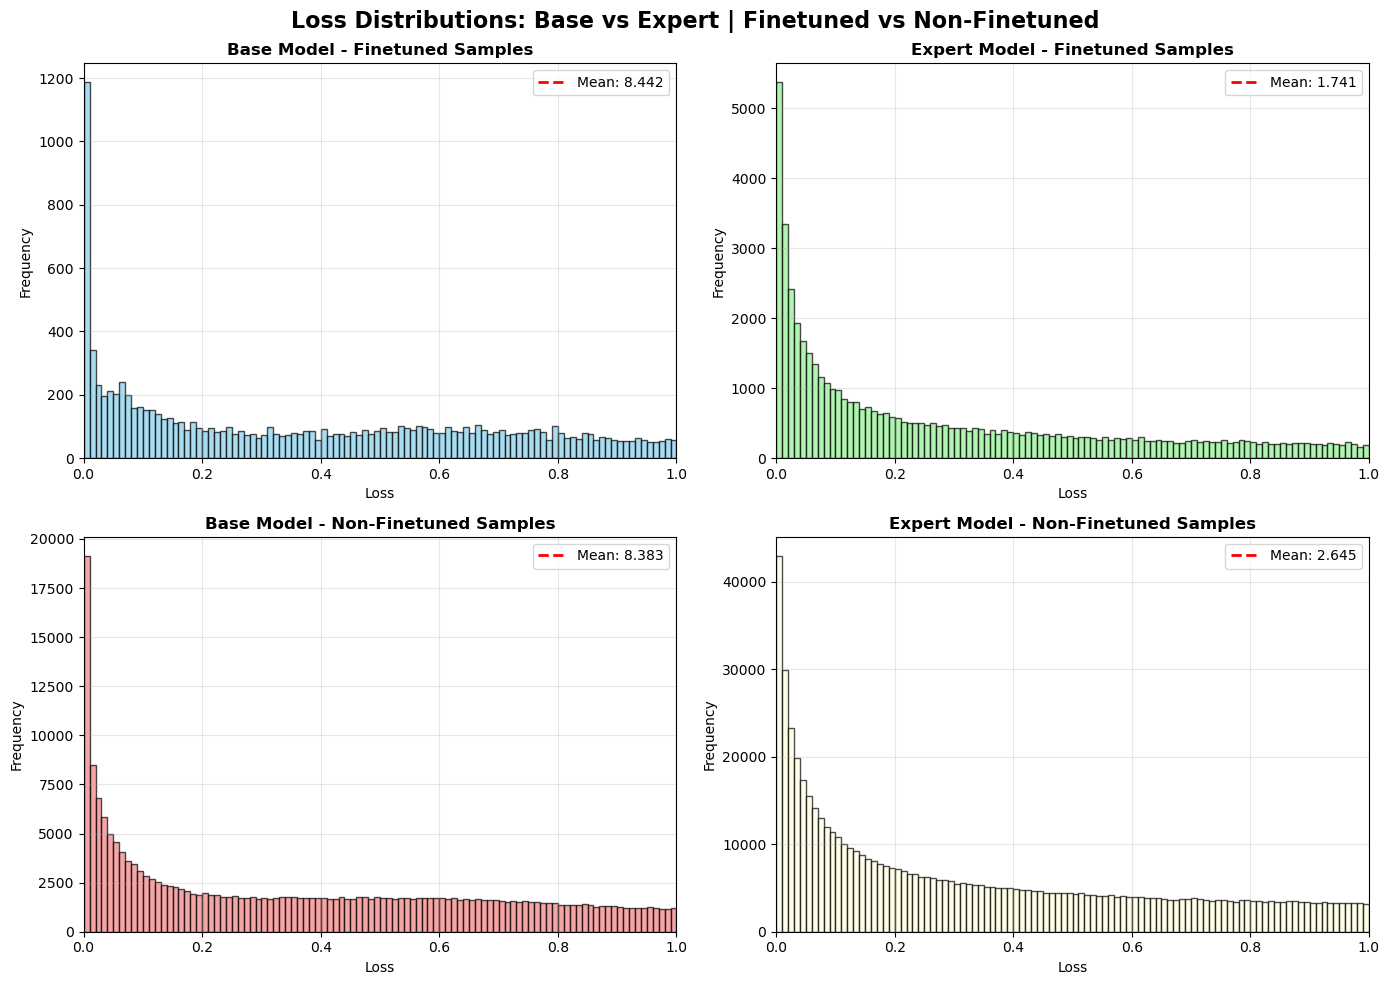


Percentage-reduction debug:
  FT  min/max: -6573299.0 99.999954
  NFT min/max: -10177142.0 100.0
  FT  mean   : -4147.482
  NFT mean   : -4527.32


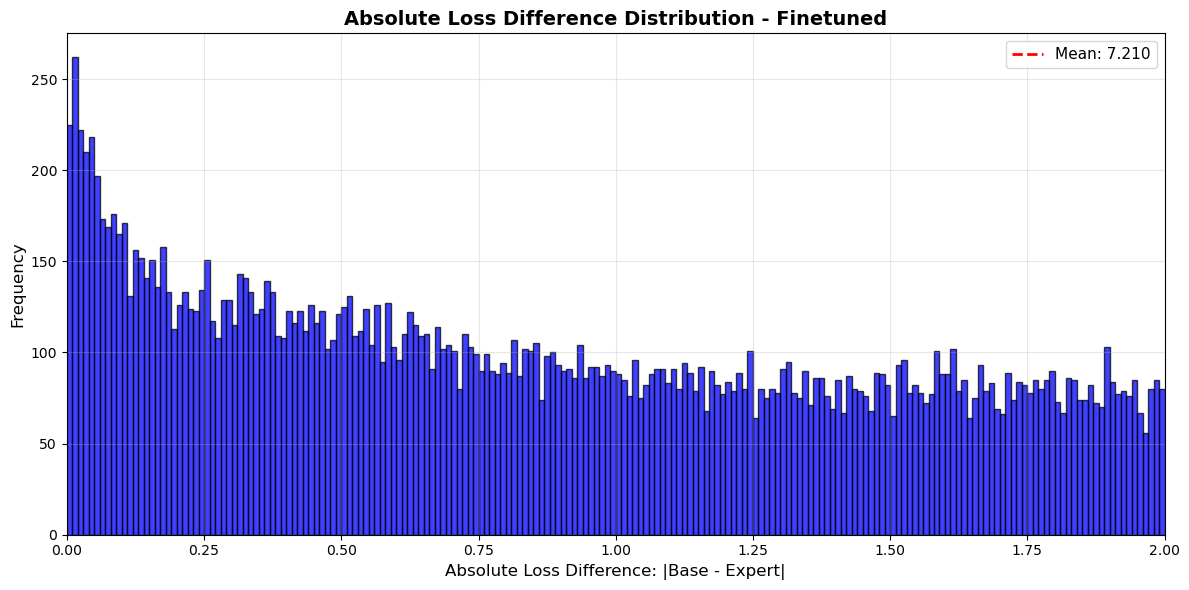

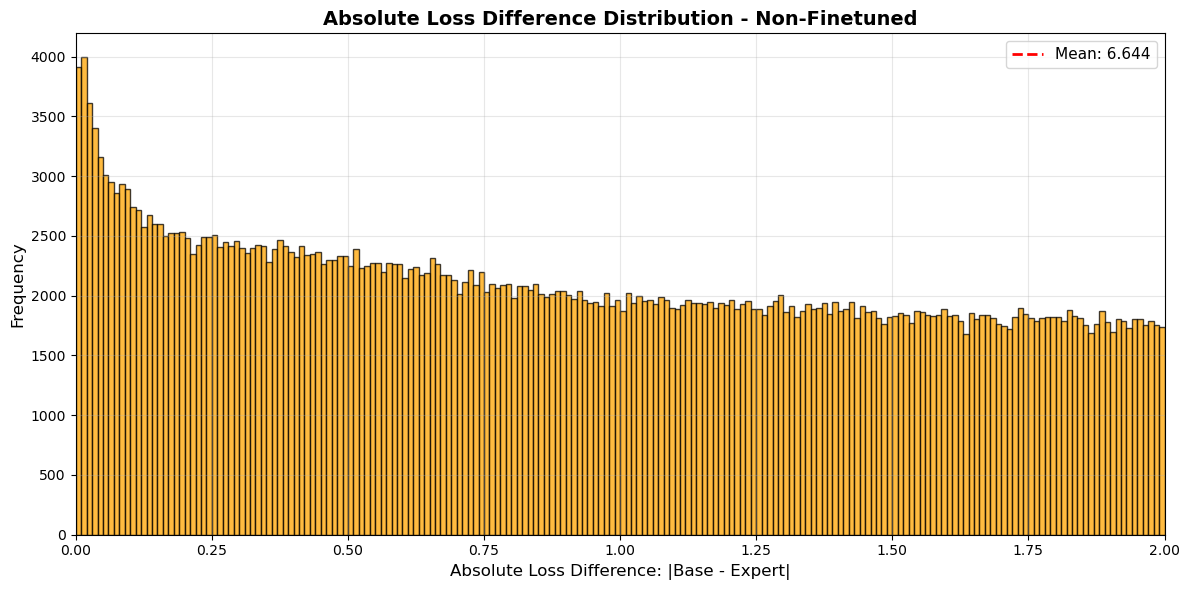

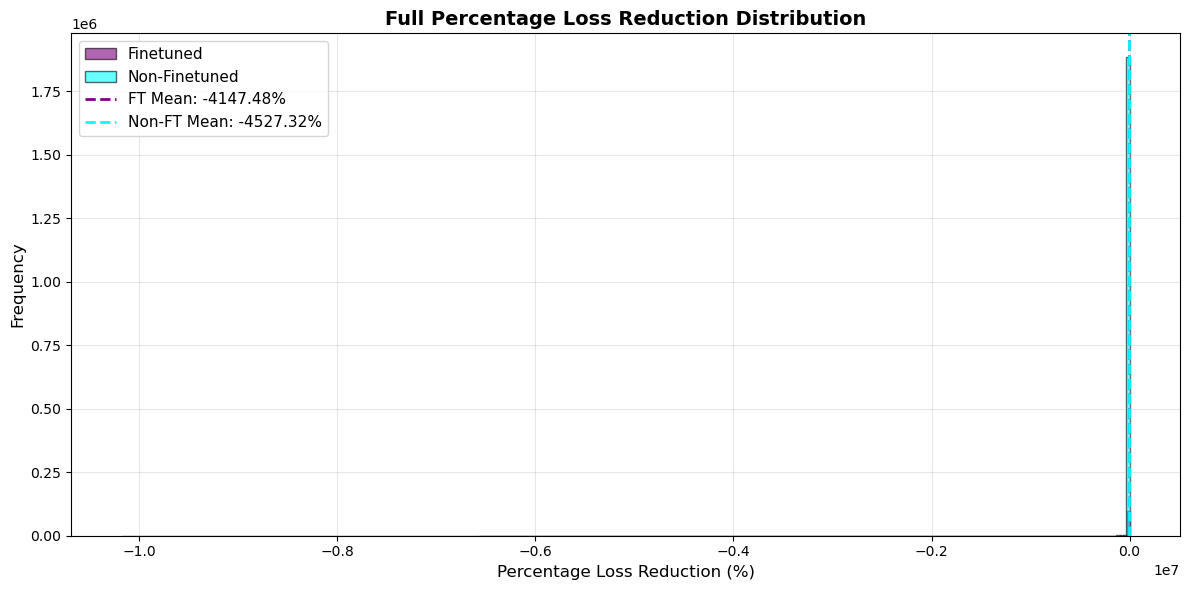

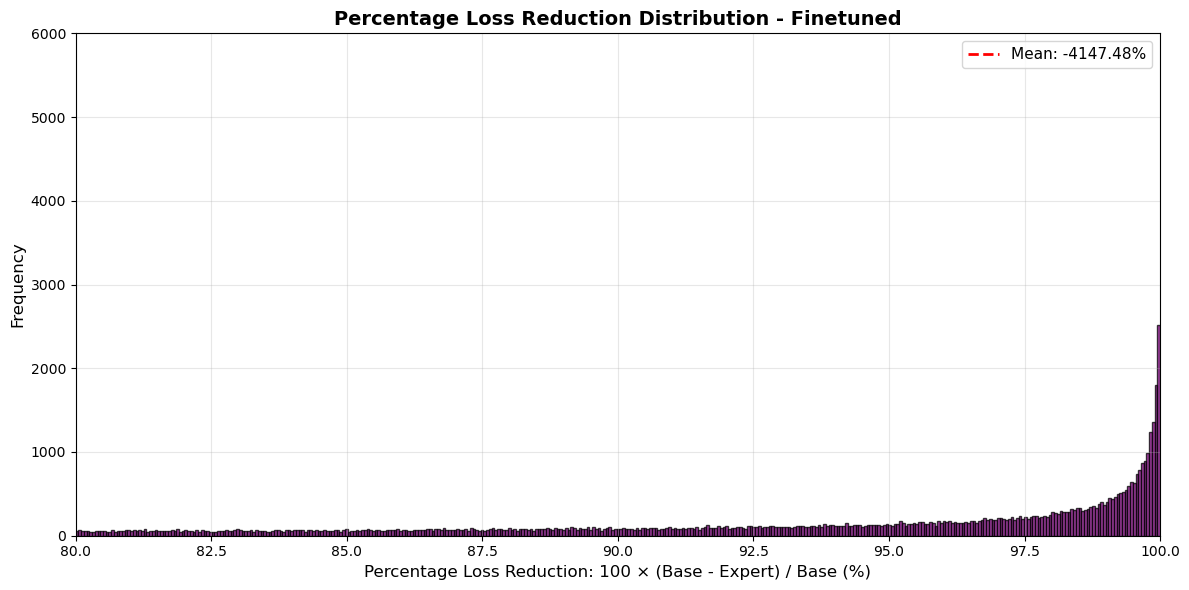

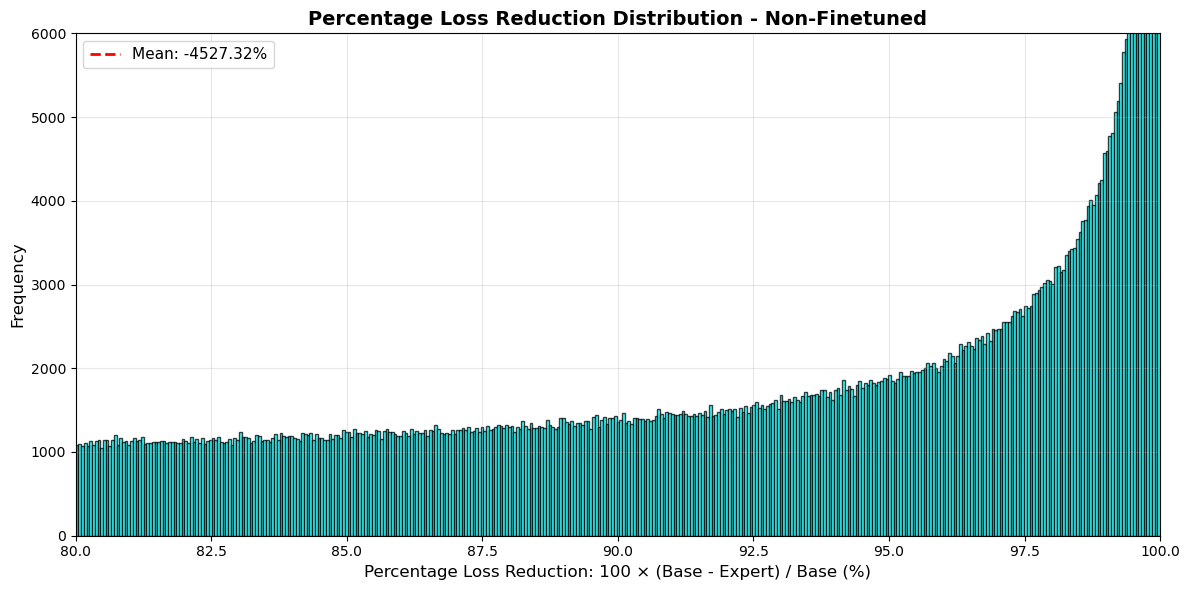

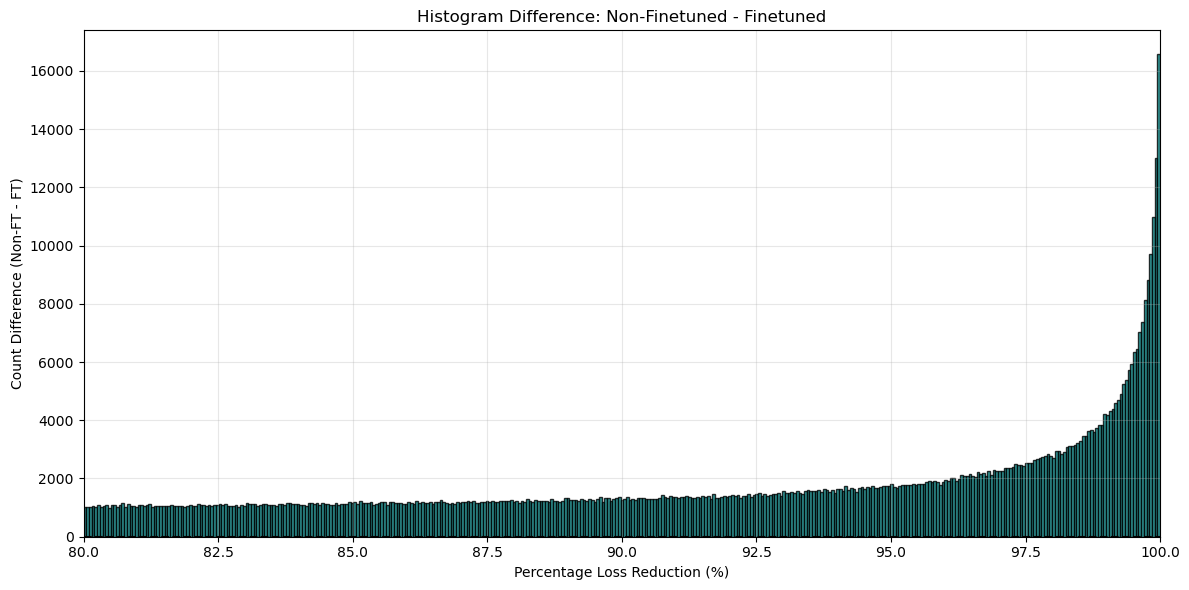


LOSS STATISTICS

Finetuned Samples:
  Base   - Mean: 8.4420, Std: 6.0027, Min: 0.0000, Max: 39.1151
  Expert - Mean: 1.7412, Std: 2.1438, Min: 0.0000, Max: 22.4952

Non-Finetuned Samples:
  Base   - Mean: 8.3826, Std: 5.9766, Min: 0.0000, Max: 42.0171
  Expert - Mean: 2.6451, Std: 2.5086, Min: -0.0000, Max: 31.4628

Absolute Loss Difference:
  Finetuned:     Mean: 7.2095, Std: 5.7233
  Non-Finetuned: Mean: 6.6435, Std: 5.4075

Percentage Loss Reduction:
  Finetuned:     Mean: -4147.48%, Std: 97391.15%
  Non-Finetuned: Mean: -4527.32%, Std: 106405.09%


In [21]:
def main():

    # Aggregate
    all_base_ft, all_base_nft = [], []
    all_expert_ft, all_expert_nft = [], []

    for exp_dir in Path(base_dir).iterdir():
        losses_file = f"{losses_dir}/{exp_dir.name}/losses.pkl"
    
        with open(losses_file, 'rb') as f:
            exp_data = pickle.load(f)
        
            base = np.array(exp_data["base_losses"])
            expert = np.array(exp_data["expert_losses"])
            is_ft = np.array(exp_data["is_finetuned"], dtype=bool)

            all_base_ft.extend(base[is_ft])
            all_base_nft.extend(base[~is_ft])
            all_expert_ft.extend(expert[is_ft])
            all_expert_nft.extend(expert[~is_ft])

    all_base_ft = np.array(all_base_ft)
    all_base_nft = np.array(all_base_nft)
    all_expert_ft = np.array(all_expert_ft)
    all_expert_nft = np.array(all_expert_nft)

    print("Counts:")
    print("  FT :", len(all_base_ft))
    print("  NFT:", len(all_base_nft))

    # =========================================================================
    # VISUALIZATION 1: Loss Histograms
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Loss Distributions: Base vs Expert | Finetuned vs Non-Finetuned",
        fontsize=16,
        fontweight="bold"
    )

    bins_loss = np.linspace(0, 1, 101)

    axes[0, 0].hist(all_base_ft, bins=bins_loss, alpha=0.7, color="skyblue", edgecolor="black")
    axes[0, 0].axvline(np.mean(all_base_ft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_base_ft):.3f}")
    axes[0, 0].set_title("Base Model - Finetuned Samples", fontweight="bold")
    axes[0, 0].set_xlabel("Loss")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 0].set_xlim(0, 1)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(all_expert_ft, bins=bins_loss, alpha=0.7, color="lightgreen", edgecolor="black")
    axes[0, 1].axvline(np.mean(all_expert_ft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_expert_ft):.3f}")
    axes[0, 1].set_title("Expert Model - Finetuned Samples", fontweight="bold")
    axes[0, 1].set_xlabel("Loss")
    axes[0, 1].set_ylabel("Frequency")
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(all_base_nft, bins=bins_loss, alpha=0.7, color="lightcoral", edgecolor="black")
    axes[1, 0].axvline(np.mean(all_base_nft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_base_nft):.3f}")
    axes[1, 0].set_title("Base Model - Non-Finetuned Samples", fontweight="bold")
    axes[1, 0].set_xlabel("Loss")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_xlim(0, 1)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].hist(all_expert_nft, bins=bins_loss, alpha=0.7, color="lightyellow", edgecolor="black")
    axes[1, 1].axvline(np.mean(all_expert_nft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_expert_nft):.3f}")
    axes[1, 1].set_title("Expert Model - Non-Finetuned Samples", fontweight="bold")
    axes[1, 1].set_xlabel("Loss")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz1_loss_histograms.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # DERIVED QUANTITIES
    # =========================================================================
    # Absolute loss difference
    loss_diff_ft = np.abs(all_base_ft - all_expert_ft)
    loss_diff_nft = np.abs(all_base_nft - all_expert_nft)

    # Stable percentage reduction: ignore tiny base losses
    eps = 1e-4
    mask_ft = all_base_ft > eps
    mask_nft = all_base_nft > eps

    pct_reduction_ft = 100 * (all_base_ft[mask_ft] - all_expert_ft[mask_ft]) / all_base_ft[mask_ft]
    pct_reduction_nft = 100 * (all_base_nft[mask_nft] - all_expert_nft[mask_nft]) / all_base_nft[mask_nft]

    print("\nPercentage-reduction debug:")
    print("  FT  min/max:", np.min(pct_reduction_ft), np.max(pct_reduction_ft))
    print("  NFT min/max:", np.min(pct_reduction_nft), np.max(pct_reduction_nft))
    print("  FT  mean   :", np.mean(pct_reduction_ft))
    print("  NFT mean   :", np.mean(pct_reduction_nft))

    # =========================================================================
    # VISUALIZATION 2A: Absolute Loss Difference - Finetuned
    # =========================================================================
    bins_diff = np.linspace(0, 2, 201)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(loss_diff_ft, bins=bins_diff, alpha=0.75, color="blue", edgecolor="black")
    ax.axvline(np.mean(loss_diff_ft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(loss_diff_ft):.3f}")
    ax.set_xlabel("Absolute Loss Difference: |Base - Expert|", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Absolute Loss Difference Distribution - Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 2)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz2a_loss_difference_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 2B: Absolute Loss Difference - Non-Finetuned
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(loss_diff_nft, bins=bins_diff, alpha=0.75, color="orange", edgecolor="black")
    ax.axvline(np.mean(loss_diff_nft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(loss_diff_nft):.3f}")
    ax.set_xlabel("Absolute Loss Difference: |Base - Expert|", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Absolute Loss Difference Distribution - Non-Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 2)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig( "viz2b_loss_difference_non_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 3FULL: Full Percentage Reduction Comparison
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(pct_reduction_ft, bins=300, alpha=0.6, label="Finetuned", color="purple", edgecolor="black")
    ax.hist(pct_reduction_nft, bins=300, alpha=0.6, label="Non-Finetuned", color="cyan", edgecolor="black")
    ax.axvline(np.mean(pct_reduction_ft), color="purple", linestyle="--", linewidth=2,
               label=f"FT Mean: {np.mean(pct_reduction_ft):.2f}%")
    ax.axvline(np.mean(pct_reduction_nft), color="cyan", linestyle="--", linewidth=2,
               label=f"Non-FT Mean: {np.mean(pct_reduction_nft):.2f}%")
    ax.set_xlabel("Percentage Loss Reduction (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Full Percentage Loss Reduction Distribution", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig( "viz3full_percentage_reduction_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 3A: Percentage Loss Reduction - Finetuned
    # =========================================================================
    bins_pct = np.linspace(80, 100, 400)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(pct_reduction_ft, bins=bins_pct, alpha=0.75, color="purple", edgecolor="black")
    ax.axvline(np.mean(pct_reduction_ft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(pct_reduction_ft):.2f}%")
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_xlabel("Percentage Loss Reduction: 100 × (Base - Expert) / Base (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Percentage Loss Reduction Distribution - Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(80, 100)
    ax.set_ylim(0, 6000)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz3a_percentage_loss_reduction_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 3B: Percentage Loss Reduction - Non-Finetuned
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(pct_reduction_nft, bins=bins_pct, alpha=0.75, color="cyan", edgecolor="black")
    ax.axvline(np.mean(pct_reduction_nft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(pct_reduction_nft):.2f}%")
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_xlabel("Percentage Loss Reduction: 100 × (Base - Expert) / Base (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Percentage Loss Reduction Distribution - Non-Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(80, 100)
    ax.set_ylim(0, 6000)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz3b_percentage_loss_reduction_non_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 4: Histogram Difference (Non-Finetuned - Finetuned)
    # =========================================================================
    counts_ft, edges = np.histogram(pct_reduction_ft, bins=bins_pct)
    counts_nft, _ = np.histogram(pct_reduction_nft, bins=bins_pct)
    counts_diff = counts_nft - counts_ft
    centers = (edges[:-1] + edges[1:]) / 2

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(centers, counts_diff, width=(edges[1] - edges[0]), color="teal", edgecolor="black", alpha=0.8)
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Percentage Loss Reduction (%)")
    ax.set_ylabel("Count Difference (Non-FT - FT)")
    ax.set_title("Histogram Difference: Non-Finetuned - Finetuned")
    ax.set_xlim(80, 100)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz4_hist_diff.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # PRINT STATS
    # =========================================================================
    print("\n" + "=" * 70)
    print("LOSS STATISTICS")
    print("=" * 70)

    print("\nFinetuned Samples:")
    print(f"  Base   - Mean: {np.mean(all_base_ft):.4f}, Std: {np.std(all_base_ft):.4f}, Min: {np.min(all_base_ft):.4f}, Max: {np.max(all_base_ft):.4f}")
    print(f"  Expert - Mean: {np.mean(all_expert_ft):.4f}, Std: {np.std(all_expert_ft):.4f}, Min: {np.min(all_expert_ft):.4f}, Max: {np.max(all_expert_ft):.4f}")

    print("\nNon-Finetuned Samples:")
    print(f"  Base   - Mean: {np.mean(all_base_nft):.4f}, Std: {np.std(all_base_nft):.4f}, Min: {np.min(all_base_nft):.4f}, Max: {np.max(all_base_nft):.4f}")
    print(f"  Expert - Mean: {np.mean(all_expert_nft):.4f}, Std: {np.std(all_expert_nft):.4f}, Min: {np.min(all_expert_nft):.4f}, Max: {np.max(all_expert_nft):.4f}")

    print("\nAbsolute Loss Difference:")
    print(f"  Finetuned:     Mean: {np.mean(loss_diff_ft):.4f}, Std: {np.std(loss_diff_ft):.4f}")
    print(f"  Non-Finetuned: Mean: {np.mean(loss_diff_nft):.4f}, Std: {np.std(loss_diff_nft):.4f}")

    print("\nPercentage Loss Reduction:")
    print(f"  Finetuned:     Mean: {np.mean(pct_reduction_ft):.2f}%, Std: {np.std(pct_reduction_ft):.2f}%")
    print(f"  Non-Finetuned: Mean: {np.mean(pct_reduction_nft):.2f}%, Std: {np.std(pct_reduction_nft):.2f}%")

main()

In [ ]:
## Compute the average MAE
## get the losses for the k points for each of the proportion
# for each proportion
# - apply that realtive threshold for all k points
# - get their label , 0 or 1 (1 means finetuned) for all k points
# - for all points marked as finetuned, compute the proportion (predicted proportion)
## compute the MAE between the true and predicted proportion
## get the average MAE 

In [11]:
model = 'gpt2'
dataset = "yahoo_answers"
base_dir = f"results_datainfo/{model}/{dataset}"
losses_dir = f"./results_losses/{model}/{dataset}"
output_dir = f"./mia_threshold_baseline_visualization/{model}/{dataset}"

In [23]:
def give_predicted_proportion(exp_dir,eps, threshold):
    losses_file = f"{losses_dir}/{exp_dir.name}/losses.pkl"
    
    with open(losses_file, 'rb') as f:
        exp_data = pickle.load(f)
    
    base_losses = np.array(exp_data['base_losses'])
    expert_losses = np.array(exp_data['expert_losses'])
    true_proportion = np.array(exp_data['true_proportion'])
    labels = np.array(exp_data['labels'])

    pct_reduction = np.full_like(base_losses, -np.inf, dtype=float)
    valid = base_losses > eps
    pct_reduction[valid] = 100 * (base_losses[valid] - expert_losses[valid]) / base_losses[valid]

    predicted_finetuned = pct_reduction > threshold

    selected_labels = labels[predicted_finetuned]

    if len(selected_labels) > 0:
        predicted_proportion = np.bincount(
            selected_labels,
            minlength=len(true_proportion)
        ).astype(float)
        predicted_proportion /= predicted_proportion.sum()
    else:
        predicted_proportion = np.zeros(len(true_proportion), dtype=float)
    
    return predicted_proportion,true_proportion

In [24]:
def evaluate_experiment(threshold, eps=1e-4):
    maes = []
    mses = []
    for exp_dir in Path(base_dir).iterdir():
        
        predicted_proportion,true_proportion = give_predicted_proportion(exp_dir,eps, threshold)

        mae = np.mean(np.abs(predicted_proportion - true_proportion))
        mse = np.mean(np.square(predicted_proportion - true_proportion))
        maes.append(mae)
        mses.append(mse)

    return np.mean(maes), np.mean(mses)


def main():
    
    
    output_dir_path = Path(output_dir)
    output_dir_path.mkdir(parents=True, exist_ok=True)
    
    
    # ============================================================
    # Sweep thresholds
    # ============================================================

    thresholds = np.linspace(30, 99.0, 50)   # fine-grained sweep
    mae_values = []
    mse_values = []

    print("Sweeping thresholds...")
    for t in thresholds:
        mae,mse = evaluate_experiment(threshold=t)
        mae_values.append(mae)
        mse_values.append(mse)
        print(f"  Threshold: {t:.2f} → MAE: {mae:.6f}")

    # Convert to numpy
    thresholds = np.array(thresholds)
    mae_values = np.array(mae_values)
    mse_values = np.array(mse_values)


    # ============================================================
    # Find best threshold
    # ============================================================

    best_idx_mae = np.argmin(mae_values)
    best_threshold_mae = thresholds[best_idx_mae]
    best_mae = mae_values[best_idx_mae]
        
    best_idx_mse = np.argmin(mse_values)
    best_threshold_mse = thresholds[best_idx_mse]
    best_mse = mse_values[best_idx_mse]

    print(f"\n{'='*70}")
    print(f"Best threshold MAE: {best_threshold_mae:.4f}")
    print(f"Best threshold MSE: {best_threshold_mse:.4f}")
    print(f"Best MAE: {best_mae:.6f}")
    print(f"Best MSE: {best_mse:.6f}")
    print(f"{'='*70}")

    # ============================================================
    # Plot MAE
    # ============================================================

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, mae_values, marker='o', linewidth=2, markersize=4, alpha=0.7)

    # Highlight best point
    plt.axvline(best_threshold_mae, linestyle='--', color='red', linewidth=2, 
                label=f'Best: {best_threshold_mae:.2f}% (MAE={best_mae:.4f})')
    plt.scatter(best_threshold_mae, best_mae, color='red', s=100, zorder=5)

    plt.xlabel("Threshold (% Loss Reduction)", fontsize=12)
    plt.ylabel("Mean Absolute Error (MAE)", fontsize=12)
    plt.title("MAE vs Threshold - Finding Optimal Classification Point", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/threshold_sweep_mae.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    
    # ============================================================
    # Plot MSE
    # ============================================================

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, mse_values, marker='o', linewidth=2, markersize=4, alpha=0.7)

    # Highlight best point
    plt.axvline(best_threshold_mse, linestyle='--', color='red', linewidth=2, 
                label=f'Best: {best_threshold_mse:.2f}% (MSE={best_mse:.4f})')
    plt.scatter(best_threshold_mse, best_mse, color='red', s=100, zorder=5)

    plt.xlabel("Threshold (% Loss Reduction)", fontsize=12)
    plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
    plt.title("MSE vs Threshold - Finding Optimal Classification Point", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/threshold_sweep_mse.png", dpi=300, bbox_inches='tight')
    plt.show()
        
    
    
    
    

    # ============================================================
    # Save results
    # ============================================================

    sweep_results = {
        'thresholds': thresholds,
        'mae_values': mae_values,
        'mse_values': mse_values,
        'best_threshold_mae': best_threshold_mae,
        'best_threshold_mse': best_threshold_mse,
        'best_mae': best_mae,
        'best_mse': best_mse,
        'total_experiments': len(mae_values)
    }

    with open(f'{output_dir}/threshold_sweep_results.pkl', 'wb') as f:
        pickle.dump(sweep_results, f)

    print("\n✓ Results saved to threshold_sweep_results.pkl")

Sweeping thresholds...
  Threshold: 30.00 → MAE: 0.062942
  Threshold: 31.41 → MAE: 0.062913
  Threshold: 32.82 → MAE: 0.062876
  Threshold: 34.22 → MAE: 0.062840
  Threshold: 35.63 → MAE: 0.062796
  Threshold: 37.04 → MAE: 0.062763
  Threshold: 38.45 → MAE: 0.062699
  Threshold: 39.86 → MAE: 0.062640
  Threshold: 41.27 → MAE: 0.062578
  Threshold: 42.67 → MAE: 0.062523
  Threshold: 44.08 → MAE: 0.062446
  Threshold: 45.49 → MAE: 0.062348
  Threshold: 46.90 → MAE: 0.062237
  Threshold: 48.31 → MAE: 0.062131
  Threshold: 49.71 → MAE: 0.062003
  Threshold: 51.12 → MAE: 0.061894
  Threshold: 52.53 → MAE: 0.061746
  Threshold: 53.94 → MAE: 0.061576
  Threshold: 55.35 → MAE: 0.061409
  Threshold: 56.76 → MAE: 0.061253
  Threshold: 58.16 → MAE: 0.061103
  Threshold: 59.57 → MAE: 0.060964
  Threshold: 60.98 → MAE: 0.060824
  Threshold: 62.39 → MAE: 0.060680
  Threshold: 63.80 → MAE: 0.060539
  Threshold: 65.20 → MAE: 0.060364
  Threshold: 66.61 → MAE: 0.060209
  Threshold: 68.02 → MAE: 0.0600

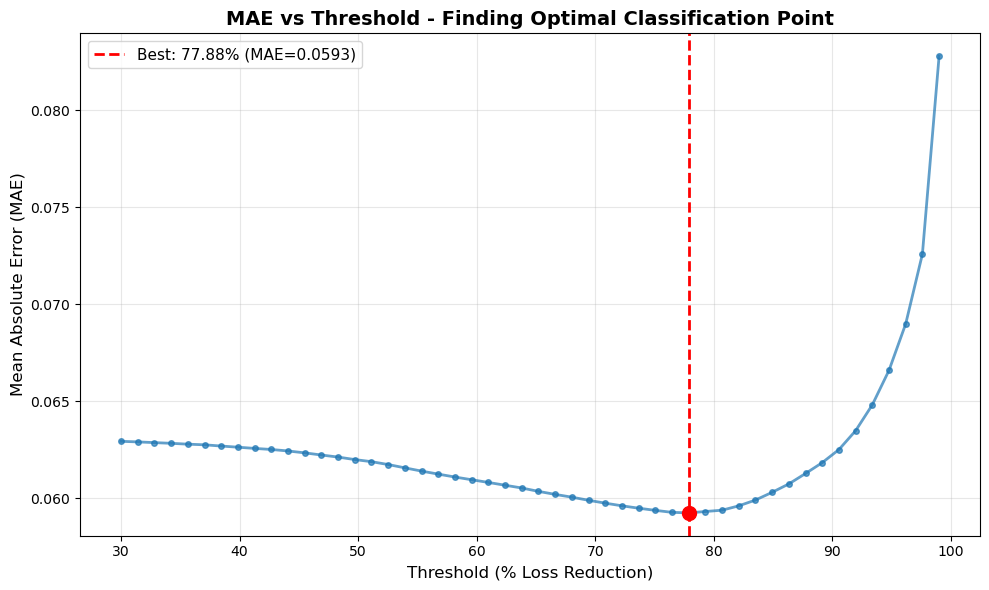

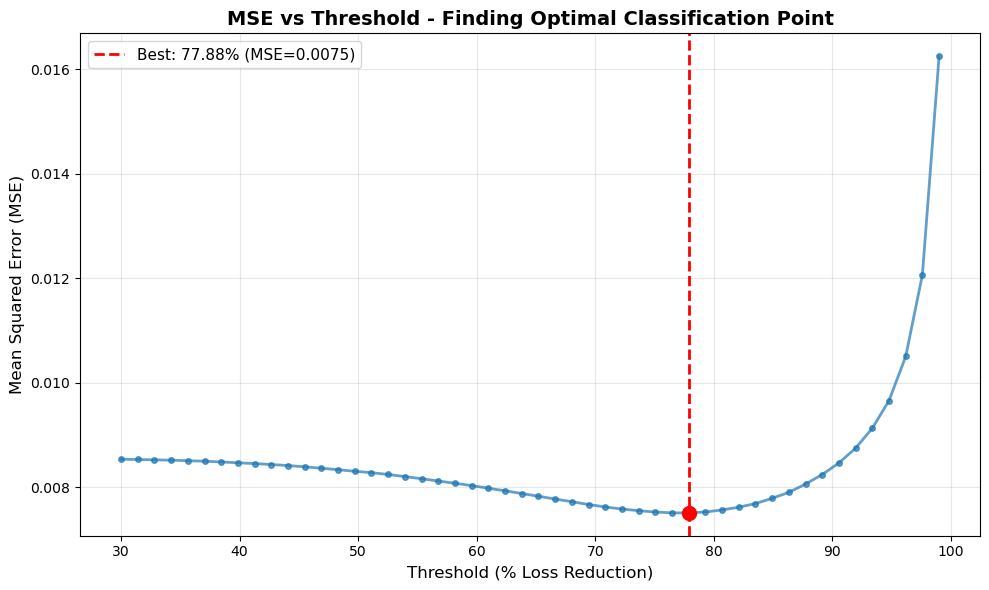


✓ Results saved to threshold_sweep_results.pkl


In [25]:
main()

## Baseline 4

### Compatibility report to see if the data info matches the align matrices

In [1]:
from pathlib import Path
import re
import json

def parse_proportion_from_dirname(dirname):
    """Extract proportion tuple from directory name like 'ag_news_(0.1, 0.3, 0.6)'"""
    match = re.search(r'[\[\(]\s*([\d., ]+)\s*[\]\)]', dirname)
    if match:
        return tuple(float(x.strip()) for x in match.group(1).split(','))
    return None

def check_compatibility(model_name, dataset_name, interpolation, 
                        datainfo_dir="./results_datainfo",
                        align_dir="./results_align_matrix"):
    """
    Check which experiments exist in datainfo but missing in align_matrix.
    
    Args:
        model_name: 'bert' or 'gpt2'
        dataset_name: 'ag_news' or 'yelp_review'
        interpolation: 'linear', 'slerp', 'ties', or 'model_baseline'
    
    Returns:
        dict with missing/extra/valid experiments
    """
    
    datainfo_path = Path(datainfo_dir) / model_name / dataset_name
    align_path = Path(align_dir) / model_name / dataset_name
    
    if not datainfo_path.exists():
        print(f"❌ Datainfo path doesn't exist: {datainfo_path}")
        return None
    
    if not align_path.exists():
        print(f"❌ Align matrix path doesn't exist: {align_path}")
        return None
    
    # Collect proportions from datainfo directories
    datainfo_proportions = {}
    for exp_dir in datainfo_path.iterdir():
        if not exp_dir.is_dir():
            continue
        
        prop = parse_proportion_from_dirname(exp_dir.name)
        if prop:
            # Check if dataset_info.json exists
            if (exp_dir / "dataset_info.json").exists():
                datainfo_proportions[prop] = str(exp_dir)
    
    # Collect proportions from align matrix directories
    align_proportions = {}
    for exp_dir in align_path.iterdir():
        if not exp_dir.is_dir():
            continue
        
        prop = parse_proportion_from_dirname(exp_dir.name)
        if prop:
            # Check if alignment matrix file exists for this interpolation
            align_file = exp_dir / f"alignment_matrix_{interpolation}.npy"
            if align_file.exists():
                align_proportions[prop] = str(exp_dir)
    
    # Find mismatches
    datainfo_set = set(datainfo_proportions.keys())
    align_set = set(align_proportions.keys())
    
    missing_in_align = datainfo_set - align_set  # In datainfo but not in align
    extra_in_align = align_set - datainfo_set    # In align but not in datainfo
    valid = datainfo_set & align_set             # In both
    
    results = {
        'model': model_name,
        'dataset': dataset_name,
        'interpolation': interpolation,
        'total_datainfo': len(datainfo_set),
        'total_align': len(align_set),
        'valid': len(valid),
        'missing_in_align': missing_in_align,
        'extra_in_align': extra_in_align,
        'datainfo_dirs': datainfo_proportions,
        'align_dirs': align_proportions
    }
    
    return results


def print_compatibility_report(results):
    """Print formatted compatibility report"""
    
    if results is None:
        return
    
    print("\n" + "="*80)
    print(f"COMPATIBILITY REPORT")
    print(f"Model: {results['model']} | Dataset: {results['dataset']} | Interpolation: {results['interpolation']}")
    print("="*80)
    
    print(f"\n📊 Summary:")
    print(f"  Total in datainfo:     {results['total_datainfo']}")
    print(f"  Total in align_matrix: {results['total_align']}")
    print(f"  ✓ Valid (in both):     {results['valid']}")
    print(f"  ❌ Missing in align:   {len(results['missing_in_align'])}")
    print(f"  ⚠️  Extra in align:     {len(results['extra_in_align'])}")
    
    if results['missing_in_align']:
        print(f"\n❌ Missing in align_matrix (need to generate):")
        for prop in sorted(results['missing_in_align']):
            datainfo_dir = results['datainfo_dirs'][prop]
            print(f"  {prop}")
            print(f"    → Datainfo: {datainfo_dir}")
    
    if results['extra_in_align']:
        print(f"\n⚠️  Extra in align_matrix (no corresponding datainfo):")
        for prop in sorted(results['extra_in_align']):
            align_dir = results['align_dirs'][prop]
            print(f"  {prop}")
            print(f"    → Align: {align_dir}")
    
    if results['valid'] > 0:
        print(f"\n✓ {results['valid']} valid experiment pairs found")


# Usage example:
if __name__ == "__main__":
    
    models = ["gpt2"]
    datasets = ["yahoo_answers"]
    interpolations = ["linear", "slerp", "ties", "model_baseline"]
    
    for model in models:
        for dataset in datasets:
            for interpolation in interpolations:
                results = check_compatibility(model, dataset, interpolation)
                print_compatibility_report(results)


COMPATIBILITY REPORT
Model: gpt2 | Dataset: yahoo_answers | Interpolation: linear

📊 Summary:
  Total in datainfo:     40
  Total in align_matrix: 40
  ✓ Valid (in both):     40
  ❌ Missing in align:   0
  ⚠️  Extra in align:     0

✓ 40 valid experiment pairs found

COMPATIBILITY REPORT
Model: gpt2 | Dataset: yahoo_answers | Interpolation: slerp

📊 Summary:
  Total in datainfo:     40
  Total in align_matrix: 40
  ✓ Valid (in both):     40
  ❌ Missing in align:   0
  ⚠️  Extra in align:     0

✓ 40 valid experiment pairs found

COMPATIBILITY REPORT
Model: gpt2 | Dataset: yahoo_answers | Interpolation: ties

📊 Summary:
  Total in datainfo:     40
  Total in align_matrix: 40
  ✓ Valid (in both):     40
  ❌ Missing in align:   0
  ⚠️  Extra in align:     0

✓ 40 valid experiment pairs found

COMPATIBILITY REPORT
Model: gpt2 | Dataset: yahoo_answers | Interpolation: model_baseline

📊 Summary:
  Total in datainfo:     40
  Total in align_matrix: 40
  ✓ Valid (in both):     40
  ❌ Missing 

In [ ]:
# this assumes that the interpolation we are generating for, is there for every specific experiment 
# this also summes that the alignment matrix is stored in the same order as the indices in the dataset info.json file
# in the earlier code, we ensure that we only train and select data from the valid indices. (with class != -1)

In [14]:
def return_data(dataset_name):
    """
    Load dataset from HuggingFace, handling special case for Yelp reviews.
    
    Args:
        dataset_name: Name of the dataset to load
        
    Returns:
        Loaded HuggingFace dataset object
    """
    # Yelp reviews require loading from 'yelp_review_full' repo
    if dataset_name == "yelp_review":
        return load_dataset("yelp_review_full")
    
    if(dataset_name=="yahoo_answers"):
        return load_dataset('mteb/yahoo_answers_topics')
    
    # All other datasets use their standard names
    return load_dataset(dataset_name)

In [15]:
def get_predicted_proportion(align_matrix_path,datainfo_path,data, num_classes):

    # Load alignment matrix (shape: [N_samples, K_experts])
    
    try:
        alignment_matrix = np.load(align_matrix_path)
    except:
        print(f"skipped {align_matrix_path}")
        return None 
    
    # Get sample indices from experiment metadata
    with open(datainfo_path, 'r', encoding='utf-8') as file:
        json_data = json.load(file)
        
    indices = json_data["indices_D"]
    train_data = data["train"]
    
    # Map indices to their class labels
    labels = np.array([train_data[idx]['label'] for idx in indices])
    
    # Compute mean alignment score for each class
    mean_alignment = []
    for i in range(num_classes):
        cls_mask = (labels == i)  # Boolean mask for class i
        cls_alignment = alignment_matrix[cls_mask]  # Get all samples from class i
        mean_alignment.append(np.mean(cls_alignment))  # Average across samples
    
    # Convert mean alignments to proportion prediction using softmax
    predicted_proportion = torch.nn.functional.softmax(torch.tensor(mean_alignment), dim=0)
    
    return predicted_proportion

In [21]:
def get_MAE(align_matrix_path,predicted_proportion,num_classes):
    
    """
    Calculate MAE between true and predicted class proportions.
    
    Uses mean alignment scores per class to predict proportions via softmax.
    """
    
    # Extract true proportion from path (e.g., [0.1, 0.3, 0.4, 0.2])
    match = re.search(r'\[([\d., ]+)\]', align_matrix_path)
    true_proportion = np.array([float(x) for x in match.group(1).split(',')])
    
    # Calculate Mean Absolute Error
    mae = np.mean(np.abs(   [  predicted_proportion[i]-true_proportion[i] for i in range(num_classes)] ))
    
    return mae

In [22]:
def get_MSE(align_matrix_path,predicted_proportion,num_classes):
    
    """
    Calculate MAE between true and predicted class proportions.
    
    Uses mean alignment scores per class to predict proportions via softmax.
    """
    
    # Extract true proportion from path (e.g., [0.1, 0.3, 0.4, 0.2])
    match = re.search(r'\[([\d., ]+)\]', align_matrix_path)
    true_proportion = np.array([float(x) for x in match.group(1).split(',')])
    
    # Calculate Mean Absolute Error
    mse = np.mean([ (predicted_proportion[i]-true_proportion[i])**2 for i in range(num_classes)] )
    
    return mse

In [26]:
def save_performance(align_dir, datainfo_dir, output_dir, interpolation, data, no_of_classes,dataset_name,checkpoint_type):    
    """
    Compute MAE for all experiments and save histogram visualization.
    
    Matches alignment and datainfo directories, calculates MAE for each,
    and generates a distribution plot.
    """
    
    # Convert paths to Path objects
    align_path = Path(align_dir)
    info_path = Path(datainfo_dir)
    output_path = Path(output_dir)
    
    # Find matching experiment directories (sorted for alignment)
    align_directories = sorted([str(d) for d in align_path.iterdir() 
                                if d.is_dir() and interpolation in str(d)])
    datainfo_directories = sorted([str(d) for d in info_path.iterdir() if d.is_dir()])
    
    # Compute MAE for each experiment
    list_MAE = []
    list_MSE = []
    for i in range(len(align_directories)): 
            
        if(checkpoint_type.strip()):
                align_matrix_path = align_directories[i] + f"/alignment_matrix_{interpolation}_{checkpoint_type}.npy"
        else:
                align_matrix_path = align_directories[i] + f"/alignment_matrix_{interpolation}.npy"
        
        
        datainfo_path = datainfo_directories[i] + f"/dataset_info.json"
        predicted_proportion = get_predicted_proportion(align_matrix_path,datainfo_path,data,no_of_classes)
        if(predicted_proportion==None):
                continue
        list_MAE.append(get_MAE(align_matrix_path,predicted_proportion,no_of_classes))
        list_MSE.append(get_MSE(align_matrix_path,predicted_proportion,no_of_classes))
    
    # Create output directory
    output_path.mkdir(parents=True, exist_ok=True)

    
    
    
    # ============================================================
    # Visualization: MAE Distribution
    # ============================================================
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Histogram of MAE values
    ax.hist(list_MAE, bins=20, range=(0, 1),
            color='skyblue', edgecolor='black', alpha=0.7)
    
    ax.set_xlim(0, 1)
    ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add mean reference line
    mean_mae = np.mean(list_MAE)
    ax.axvline(mean_mae, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_mae:.3f}')
    ax.legend()
    
    plt.suptitle(f'MAE Distribution ( {interpolation}, {dataset_name} ',
                 fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    # Save and close
    save_path = output_path / 'mae_histogram.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Saved: {save_path} (Mean MAE: {mean_mae:.4f})")
    
    
    
    
    # ============================================================
    # Visualization: MSE Distribution
    # ============================================================
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Histogram of MAE values
    ax.hist(list_MSE, bins=20, range=(0, 1),
            color='skyblue', edgecolor='black', alpha=0.7)
    
    ax.set_xlim(0, 1)
    ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add mean reference line
    mean_mse = np.mean(list_MSE)
    ax.axvline(mean_mse, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_mse:.3f}')
    ax.legend()
    
    plt.suptitle(f'MSE Distribution ( {interpolation}, {dataset_name} ',
                 fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    # Save and close
    save_path = output_path / 'mse_histogram.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Saved: {save_path} (Mean MSE: {mean_mse:.4f})")

In [27]:
output_dir = "./one_layer_baseline_visualizations"
align_matrix_dir = "./results_align_matrix"
datainfo_dir = "./results_datainfo"
interpolations = ["model_baseline","slerp","ties","linear"]
models = ["gpt2"]
datasets = [ "yahoo_answers"]
no_of_classes = [10]
checkpoint_types = [" "]

In [28]:
# Evaluate baseline performance across all model/dataset/interpolation combinations
for model_name in models:
    j = 0  # Track dataset index for class count lookup
    
    for dataset_name in datasets:
        # Load dataset once per dataset (reused across interpolations)
        data = return_data(dataset_name)
        
        for interpolation_name in interpolations:
            
            for checkpoint_type in checkpoint_types:
                
                # Build paths for this specific configuration
                align_path = f"./{align_matrix_dir}/{model_name}/{dataset_name}"
                datainfo_path = f"./{datainfo_dir}/{model_name}/{dataset_name}"
                
                if(checkpoint_type.strip()):
                    output_path = f"./{output_dir}/{model_name}/{dataset_name}/{interpolation_name}/{checkpoint_type}"
                else:
                    output_path = f"./{output_dir}/{model_name}/{dataset_name}/{interpolation_name}/simple"
                
                # Compute and save MAE histogram for this interpolation method
                save_performance(align_path, datainfo_path, output_path,
                                interpolation_name, data, no_of_classes[j],dataset_name,checkpoint_type)
        
        j += 1  # Move to next dataset's class count

✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/model_baseline/simple/mae_histogram.png (Mean MAE: 0.0919)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/model_baseline/simple/mse_histogram.png (Mean MSE: 0.0187)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/slerp/simple/mae_histogram.png (Mean MAE: 0.1252)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/slerp/simple/mse_histogram.png (Mean MSE: 0.0362)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/ties/simple/mae_histogram.png (Mean MAE: 0.0641)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/ties/simple/mse_histogram.png (Mean MSE: 0.0084)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/linear/simple/mae_histogram.png (Mean MAE: 0.0641)
✓ Saved: one_layer_baseline_visualizations/gpt2/yahoo_answers/linear/simple/mse_histogram.png (Mean MSE: 0.0084)


In [ ]:
# import pickle as pl

# align_path = Path("./")

# # Find matching experiment directories (sorted for alignment)
# yelp_directories = sorted([str(d) for d in align_path.iterdir() 
#                             if d.is_dir() and "yelp_review_(" in str(d)])

# for dir in yelp_directories:
#     print(dir)
#     with open(f'{dir}/accuracy_arr.pkl','rb') as f:
#         print(pl.load(f))